In [81]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import average_precision_score
from sklearn.metrics import accuracy_score, classification_report, recall_score, f1_score, precision_score, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Documentation of meanings of each column
age: person's age

sex: gender (male or female)

race: race category (white, asian or pacific islander, amer indian aleut or eskimo, black, other)

hispanic origin: hispanic ethinicity

citizenship: citizenship status

country of birth (self, father, mother): birth country

education: highest education completed

enroll in edu inst last wk: whether enrolled in school recently

class of worker: employment type

detailed industry recode: detailed industry classification

detailed occupation recode: detailed occupation classification

full or part time employment stat: full time vs part time status

marital stat: marital status

major industry code: broad industry category

major occupation code: broad occupation category

wage per hour: hourly wage income

member of a labor union: whether person belongs to a labor union

reason for unemployment: reason currently unemployed

capital gains: profit from investments or asset sales

capital losses: investment or asset losses

dividends from stocks: income earned from stock dividends

tax filer stat: tax filing status

region of previous residence: previous geographic region lived in

state of previous residence: previous state lived in

detailed household and family stat: detailed household/family structure

detailed household summary in household: summarized household composition

weight: survey sample weight representing population proportion

migration code-change in msa: migration change across metropolitan statistical areas

migration code-change in reg: migration change across regions

migration code-move within reg: migration movement within same region

live in this house 1 year ago: whether person lived in same house one year ago

migration prev res in sunbelt: whether previous residence was in the Sunbelt region

num persons worked for employer: number of employees in employer's company

family members under 18: family status involving members under age 18

country of birth father: father's birth country

country of birth mother: mother's birth country

country of birth self: person's birth country

own business or self employed: whether person owns business or is self-employed

fill inc questionnaire for veteran's admin: whether income questionnaire completed for veteran administration

veterans benefits: veteran benefit status or amount received

weeks worked in year: number of weeks worked during the year

year: survey year (1994 or 1995)

label: income category target label (>50K or <=50K)




# Data preprocessing and EDA

## 1. Data cleaning and transformation

Read file and convert into one single dataframe

In [82]:
columns = pd.read_csv("census-bureau.columns", header=None)
data = pd.read_csv("census-bureau.data", header=None)
data.columns = columns[0].tolist()
data.head()

,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,...,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.


## Handling missing value

In [83]:
# Remove leading/trailing spaces from string values
data = data.map(lambda x: x.strip() if isinstance(x, str) else x)

# Treat "?" as missing
data_with_nan = data.replace("?", np.nan)

missing_summary = pd.DataFrame({
    "column": data_with_nan.columns,
    "dtype": data_with_nan.dtypes.values,
    "total_missing": data_with_nan.isna().sum().values,
    "missing_percent": (data_with_nan.isna().sum() / len(data_with_nan) * 100).round(2).values,
    "num_unique": data_with_nan.nunique(dropna=True).values
})

missing_summary


,column,dtype,total_missing,missing_percent,num_unique
0,age,int64,0,0.00,91
1,class of worker,object,0,0.00,9
2,detailed industry recode,int64,0,0.00,52
3,detailed occupation recode,int64,0,0.00,47
4,education,object,0,0.00,17
5,wage per hour,int64,0,0.00,1240
6,enroll in edu inst last wk,object,0,0.00,3
7,marital stat,object,0,0.00,7
8,major industry code,object,0,0.00,24
9,major occupation code,object,0,0.00,15


In [84]:
df_clean = data.copy()
df_clean = df_clean.map(lambda x: x.strip() if isinstance(x, str) else x)
df_clean = df_clean.replace("?", np.nan)
missing_rate = df_clean.isna().mean()
cols_to_drop = missing_rate[missing_rate > 0.4].index.tolist()

print(f"Columns to drop {cols_to_drop}")

# Drop those columns
df_clean = df_clean.drop(columns=cols_to_drop)

# For remaining missing values:
# fill object/category columns with "missing"
cat_cols = df_clean.select_dtypes(include=["object"]).columns
df_clean[cat_cols] = df_clean[cat_cols].fillna("missing")
# Check result
missing_check = pd.DataFrame({
    "column": df_clean.columns,
    "total_missing": df_clean.isna().sum().values,
    "missing_percent": (df_clean.isna().mean() * 100).round(2).values,
    "dtype": df_clean.dtypes.values
})

missing_check

Columns to drop ['migration code-change in msa', 'migration code-change in reg', 'migration code-move within reg', 'migration prev res in sunbelt']


,column,total_missing,missing_percent,dtype
0,age,0,0.0,int64
1,class of worker,0,0.0,object
2,detailed industry recode,0,0.0,int64
3,detailed occupation recode,0,0.0,int64
4,education,0,0.0,object
5,wage per hour,0,0.0,int64
6,enroll in edu inst last wk,0,0.0,object
7,marital stat,0,0.0,object
8,major industry code,0,0.0,object
9,major occupation code,0,0.0,object


There is a issue about numerical value. Wage per hour, capital gains, capital losses, dividends from stocks, num persons worked for employees and weeks worked in year are columns that are in numerical value, however most of the values in these columns are zeros.

So, in order to deal with this situation, we add an indicator column for each variables to account this situation. we can think of adding an bias term to each of this variable to count in the effect of being zero.

In [85]:
numeric_cols = [
    "wage per hour",
    "capital gains",
    "capital losses",
    "dividends from stocks",
    "num persons worked for employer",
    "weeks worked in year"
]

zero_summary = pd.DataFrame({
    "column": numeric_cols,
    "num_zero": [(df_clean[col] == 0).sum() for col in numeric_cols],
    "zero_percent": [(df_clean[col] == 0).mean() * 100 for col in numeric_cols],
    "min": [df_clean[col].min() for col in numeric_cols],
    "max": [df_clean[col].max() for col in numeric_cols],
    "mean": [df_clean[col].mean() for col in numeric_cols],
    "median": [df_clean[col].median() for col in numeric_cols]
})

zero_summary

,column,num_zero,zero_percent,min,max,mean,median
0,wage per hour,188219,94.334488,0,9999,55.426908,0.0
1,capital gains,192144,96.301680,0,99999,434.718990,0.0
2,capital losses,195617,98.042331,0,4608,37.313788,0.0
3,dividends from stocks,178382,89.404229,0,99999,197.529533,0.0
4,num persons worked for employer,95983,48.106233,0,6,1.956180,1.0
5,weeks worked in year,95983,48.106233,0,52,23.174897,8.0


In [86]:
df_model = df_clean.copy()
for col in numeric_cols:
    df_model[col + "_is_nonzero"] = (df_model[col] != 0).astype(int)

Columns like capital gains, capital losses, and dividends from stocks are skewed. Therefore, I use log transformation to mitigate this effect.

In [87]:
skewed_money_cols = [
    "wage per hour",
    "capital gains",
    "capital losses",
    "dividends from stocks"
]

for col in skewed_money_cols:
    df_model[col + "_log"] = np.log1p(df_model[col])

In [88]:
df_model["label"] = df_model["label"].map({
    "- 50000.": 0,
    "50000+.": 1
})

### EDA

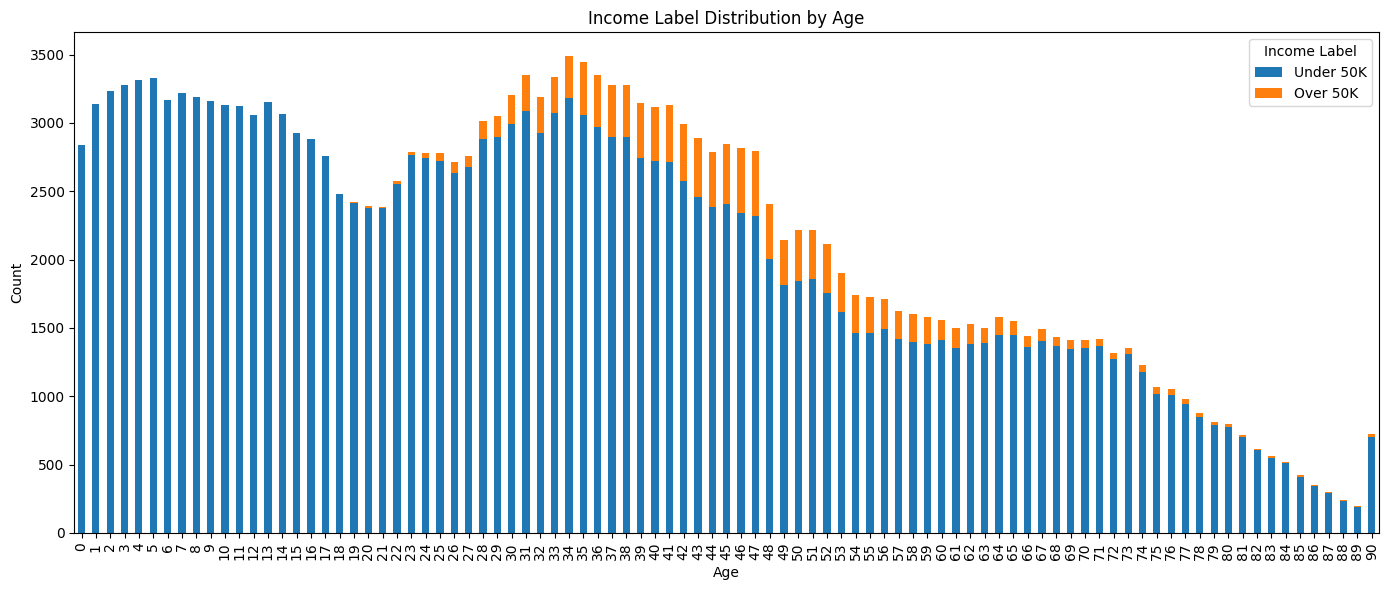

In [89]:
age_label_counts = (
    df_model
    .groupby(['age', 'label'])
    .size()
    .unstack(fill_value=0)
)

age_label_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 6)
)

plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Income Label Distribution by Age')
plt.legend(
    title='Income Label',
    labels=['Under 50K', 'Over 50K']
)
plt.tight_layout()
plt.show()

In [90]:
df_model['age_group'] = pd.cut(
    df_model['age'],
    bins=[-1, 29, 59, 90],
    labels=['0-29', '29-59', '60-90']
)

age_group_pct = (
    df_model
    .groupby(['age_group', 'label'])
    .size()
    .unstack(fill_value=0)
)

age_group_pct = age_group_pct.div(age_group_pct.sum(axis=1), axis=0) * 100

age_group_pct = age_group_pct.rename(columns={
    0: 'under_50k_pct',
    1: 'over_50k_pct'
})

age_group_pct

/var/folders/6j/kqg40c5s2n73_6qhx00mxd7r0000gn/T/ipykernel_74317/2931443213.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['age_group', 'label'])


label,under_50k_pct,over_50k_pct
age_group,,
0-29,99.315815,0.684185
29-59,87.209185,12.790815
60-90,94.933817,5.066183


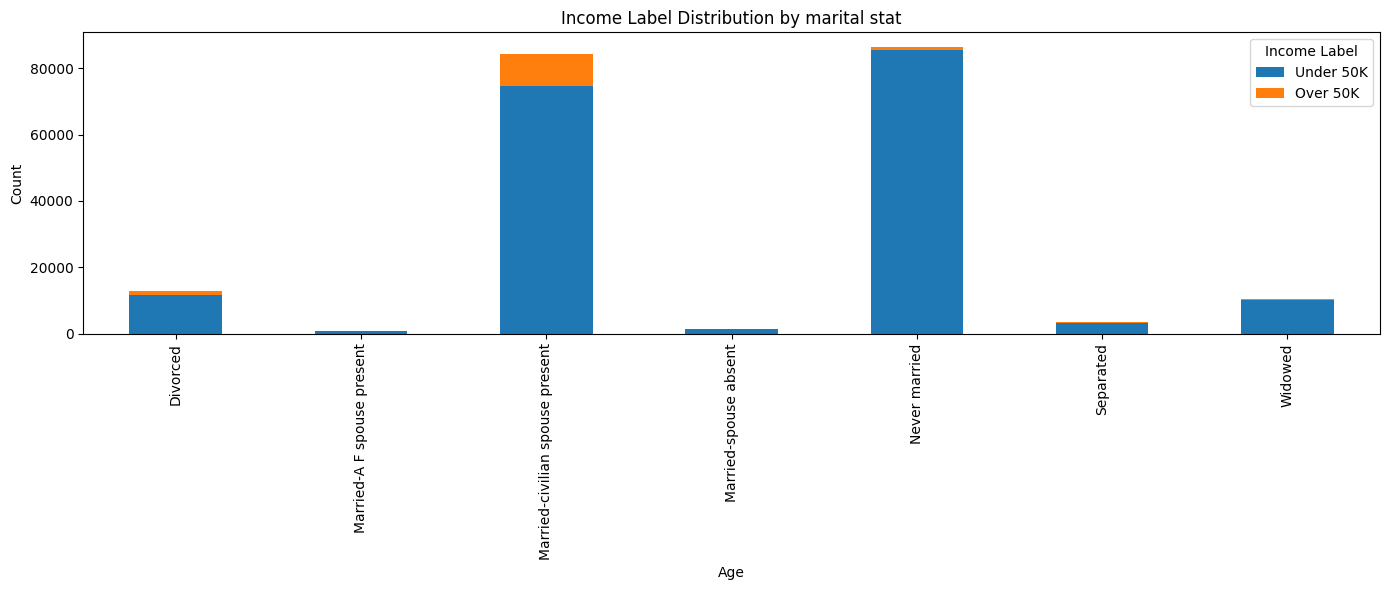

In [91]:
age_label_counts = (
    df_model
    .groupby(['marital stat', 'label'])
    .size()
    .unstack(fill_value=0)
)

age_label_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 6)
)

plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Income Label Distribution by marital stat')
plt.legend(
    title='Income Label',
    labels=['Under 50K', 'Over 50K']
)
plt.tight_layout()
plt.show()

Based on the income label distribution across marital status categories, I grouped the feature into two categories: Divorced or Married-civilian spouse present and Other. This grouping was chosen because both divorced individuals and those with a civilian spouse present show a relatively stronger presence of the over-50K income label compared with the remaining categories. In contrast, the other marital status groups are more heavily dominated by the under-50K label. Therefore, this recoding simplifies the feature while still retaining the main pattern between marital status and income.

In [92]:
df_model['marital_group'] = df_model['marital stat'].apply(
    lambda x: 'Divorced_or_Married' if x in ['Divorced', 'Married-civilian spouse present'] else 'Other'
)

In [93]:
df_encoded = df_model.copy()
exclude_cols = ["education", "label", 'age', 'marital stat']

# Select categorical columns except education and label
categorical_cols = [
    col for col in df_encoded.select_dtypes(include=["object", "category"]).columns
    if col not in exclude_cols
]

categorical_cols.extend(['detailed industry recode', 'detailed occupation recode', 'own business or self employed'])
print("Categorical columns to one-hot encode:")
print(categorical_cols)

# One-hot encode selected categorical columns
df_encoded = pd.get_dummies(
    df_encoded,
    columns=categorical_cols,
    drop_first=False,
    dtype=int
)

Categorical columns to one-hot encode:
['class of worker', 'enroll in edu inst last wk', 'major industry code', 'major occupation code', 'race', 'hispanic origin', 'sex', 'member of a labor union', 'reason for unemployment', 'full or part time employment stat', 'tax filer stat', 'region of previous residence', 'state of previous residence', 'detailed household and family stat', 'detailed household summary in household', 'live in this house 1 year ago', 'family members under 18', 'country of birth father', 'country of birth mother', 'country of birth self', 'citizenship', "fill inc questionnaire for veteran's admin", 'age_group', 'marital_group', 'detailed industry recode', 'detailed occupation recode', 'own business or self employed']


In [94]:
label_counts = df_model["label"].value_counts()
label_pct = df_model["label"].value_counts(normalize=True) * 100

pd.DataFrame({
    "count": label_counts,
    "percent": label_pct.round(2)
})

,count,percent
label,,
0,187141,93.79
1,12382,6.21


In [95]:
edu_income = (
    df_model
    .groupby("education")["label"]
    .agg(["count", "mean"])
    .reset_index()
)

edu_income["over_50k_pct"] = edu_income["mean"] * 100
edu_income = edu_income.sort_values("over_50k_pct", ascending=False)
edu_income

,education,count,mean,over_50k_pct
15,Prof school degree (MD DDS DVM LLB JD),1793,0.540435,54.043503
11,Doctorate degree(PhD EdD),1263,0.520190,52.019002
14,Masters degree(MA MS MEng MEd MSW MBA),6541,0.311573,31.157315
9,Bachelors degree(BA AB BS),19865,0.197080,19.708029
7,Associates degree-academic program,4363,0.094430,9.443044
8,Associates degree-occup /vocational,5358,0.077081,7.708100
16,Some college but no degree,27820,0.064234,6.423436
12,High school graduate,48407,0.038817,3.881670
2,12th grade no diploma,2126,0.015992,1.599247
1,11th grade,6876,0.010180,1.018034


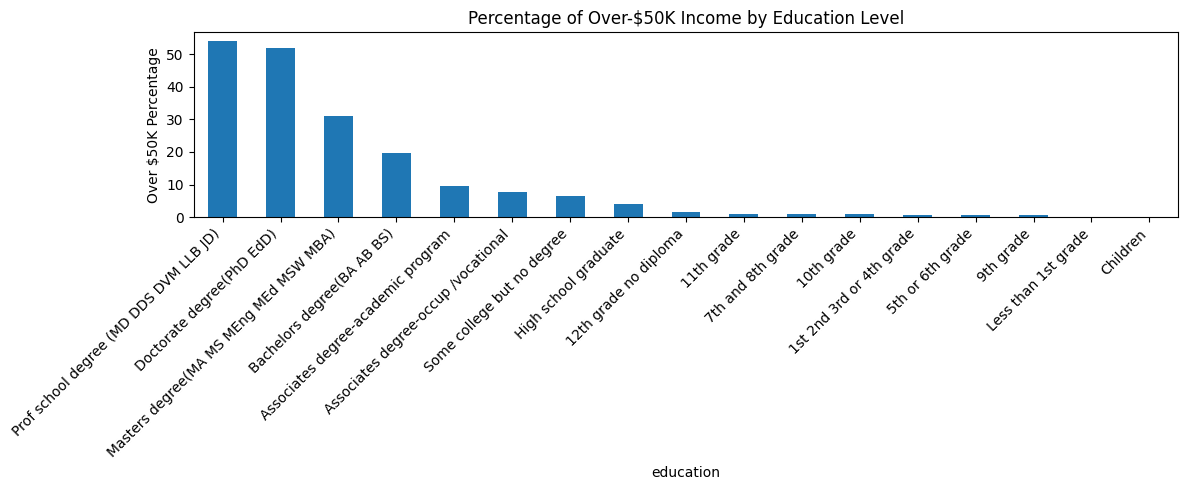

In [96]:
edu_income.plot(
    x="education",
    y="over_50k_pct",
    kind="bar",
    figsize=(12, 5),
    legend=False
)

plt.ylabel("Over $50K Percentage")
plt.title("Percentage of Over-$50K Income by Education Level")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Higher education groups are more likely to be high-income customers, so they may be better targets for premium products, professional services, financial products, technology, or loyalty programs.

In [97]:
occupation_income = (
    df_model
    .groupby("major occupation code")["label"]
    .agg(["count", "mean"])
    .reset_index()
)

occupation_income["over_50k_pct"] = occupation_income["mean"] * 100

occupation_income = occupation_income[occupation_income["count"] >= 100]
occupation_income = occupation_income.sort_values("over_50k_pct", ascending=False)

occupation_income.head(10)

,major occupation code,count,mean,over_50k_pct
2,Executive admin and managerial,12495,0.287555,28.755502
10,Professional specialty,13940,0.249283,24.928264
11,Protective services,1661,0.155930,15.593016
12,Sales,11783,0.129339,12.933888
13,Technicians and related support,3018,0.119616,11.961564
8,Precision production craft & repair,10518,0.090797,9.079673
14,Transportation and material moving,4020,0.064428,6.442786
3,Farming forestry and fishing,3146,0.050858,5.085823
5,Machine operators assmblrs & inspctrs,6379,0.036840,3.683963
0,Adm support including clerical,14837,0.030060,3.005999


managerial, professional, and technical workers are more likely to be high-income customers. These groups can be targeted with higher-margin products or premium campaigns.

In [98]:
employment_income = (
    df_model
    .groupby("full or part time employment stat")["label"]
    .agg(["count", "mean"])
    .reset_index()
)

employment_income["over_50k_pct"] = employment_income["mean"] * 100
employment_income.sort_values("over_50k_pct", ascending=False)

,full or part time employment stat,count,mean,over_50k_pct
1,Full-time schedules,40736,0.131726,13.172624
4,PT for econ reasons usually PT,1209,0.128205,12.820513
5,PT for non-econ reasons usually FT,3322,0.118302,11.830223
3,PT for econ reasons usually FT,525,0.059048,5.904762
0,Children or Armed Forces,123769,0.047459,4.745938
6,Unemployed full-time,2311,0.035915,3.591519
7,Unemployed part- time,843,0.021352,2.135231
2,Not in labor force,26808,0.017234,1.723366


full-time workers likely have more stable purchasing power, so they are useful for identifying customers who may respond to recurring purchases, loyalty programs, or premium offers.

In [99]:
household_income = (
    df_model
    .groupby("detailed household summary in household")["label"]
    .agg(["count", "mean"])
    .reset_index()
)

household_income["over_50k_pct"] = household_income["mean"] * 100
household_income = household_income[household_income["count"] >= 100]
household_income.sort_values("over_50k_pct", ascending=False)

,detailed household summary in household,count,mean,over_50k_pct
4,Householder,75475,0.127870,12.787016
7,Spouse of householder,41709,0.054712,5.471241
5,Nonrelative of householder,7601,0.030785,3.078542
6,Other relative of householder,9703,0.008863,0.886324
0,Child 18 or older,14430,0.008732,0.873181
3,Group Quarters- Secondary individual,132,0.007576,0.757576
2,Child under 18 never married,50426,0.000040,0.003966


In [100]:
education_order = {
    "Children": 0,
    "Less than 1st grade": 1,
    "1st 2nd 3rd or 4th grade": 2,
    "5th or 6th grade": 3,
    "7th and 8th grade": 4,
    "9th grade": 5,
    "10th grade": 6,
    "11th grade": 7,
    "12th grade no diploma": 8,
    "High school graduate": 9,
    "Some college but no degree": 10,
    "Associates degree-occup /vocational": 11,
    "Associates degree-academic program": 12,
    "Bachelors degree(BA AB BS)": 13,
    "Masters degree(MA MS MEng MEd MSW MBA)": 14,
    "Doctorate degree(PhD EdD)": 15,
    "Prof school degree (MD DDS DVM LLB JD)": 16
}

df_model["education_ordinal"] = df_model["education"].map(education_order)

In [101]:
exclude_cols = [
    "label",
    "weight",
    "education",
    "marital stat",
    "age_group"
]

categorical_cols = [
    col for col in df_model.select_dtypes(include=["object", "category"]).columns
    if col not in exclude_cols
]

categorical_cols.append('own business or self employed')
print(categorical_cols)
df_encoded = pd.get_dummies(
    df_model,
    columns=categorical_cols,
    drop_first=False,
    dtype=int
)

['class of worker', 'enroll in edu inst last wk', 'major industry code', 'major occupation code', 'race', 'hispanic origin', 'sex', 'member of a labor union', 'reason for unemployment', 'full or part time employment stat', 'tax filer stat', 'region of previous residence', 'state of previous residence', 'detailed household and family stat', 'detailed household summary in household', 'live in this house 1 year ago', 'family members under 18', 'country of birth father', 'country of birth mother', 'country of birth self', 'citizenship', "fill inc questionnaire for veteran's admin", 'marital_group', 'own business or self employed']


In [102]:

cols_to_drop = [
    "education",
    "marital stat",
    "age_group"
]

df_encoded = df_encoded.drop(
    columns=[col for col in cols_to_drop if col in df_encoded.columns]
)

Final trainign dataframe

In [103]:
df_train = df_encoded.copy()

cols_to_exclude = ['weight', 'year', 'detailed industry recode', 'detailed occupation recode', 'wage per hour', 'capital gains', 'capital losses', 'dividends from stocks']

df_train = df_train.drop(columns=cols_to_exclude, errors="ignore")

X = df_train.drop(columns=["label"])
y = df_train["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (199523, 359)
y shape: (199523,)


# Trainging Proecess

### 1. Base line model - Logistic Regression

In [159]:
# data splitting
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)

X_dev, X_test, y_dev, y_test = train_test_split(X_temp, y_temp, test_size=0.5,random_state=42, stratify=y_temp)


In [160]:
# normalize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_dev_scaled = scaler.transform(X_dev)
X_test_scaled = scaler.transform(X_test)

# train model
logr = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
logr.fit(X_train_scaled, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [161]:
y_dev_predicted = logr.predict(X_dev_scaled)

print(f"Dev set accuracy is {accuracy_score(y_dev, y_dev_predicted)}")
print(classification_report(y_dev, y_dev_predicted))

Dev set accuracy is 0.8561583761433404
              precision    recall  f1-score   support

           0       0.99      0.85      0.92     37428
           1       0.29      0.91      0.44      2477

    accuracy                           0.86     39905
   macro avg       0.64      0.88      0.68     39905
weighted avg       0.95      0.86      0.89     39905



From the above classification report, we can see that  the model is predicting too many people as class 1 (over 50k). It catches most true 1s, but many predicted 1s are actually class 0. So, I'm trying to raise the decisino threshold above the default 0.5.

In [162]:
y_dev_proba = logr.predict_proba(X_dev_scaled)[:, 1]
thresholds = np.arange(0.1, 0.91, 0.05)

results = []

for threshold in thresholds:
    y_pred = (y_dev_proba >= threshold).astype(int)
    
    results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_dev, y_pred),
        "precision_class_1": precision_score(y_dev, y_pred, pos_label=1, zero_division=0),
        "recall_class_1": recall_score(y_dev, y_pred, pos_label=1, zero_division=0),
        "f1_class_1": f1_score(y_dev, y_pred, pos_label=1, zero_division=0)
    })

threshold_results = pd.DataFrame(results)

threshold_results

,threshold,accuracy,precision_class_1,recall_class_1,f1_class_1
0,0.10,0.632627,0.143292,0.987889,0.250281
1,0.15,0.683097,0.161462,0.979007,0.277206
2,0.20,0.721313,0.178805,0.971336,0.302015
3,0.25,0.752587,0.195888,0.961647,0.325477
4,0.30,0.778474,0.213198,0.954784,0.348563
5,0.35,0.800677,0.230595,0.946306,0.370827
6,0.40,0.821752,0.250216,0.937424,0.394999
7,0.45,0.838968,0.268278,0.922891,0.415712
8,0.50,0.856158,0.289511,0.905935,0.438795
9,0.55,0.872096,0.312062,0.880501,0.460807


In [163]:
best_threshold = threshold_results.loc[
    threshold_results["f1_class_1"].idxmax(), 
    "threshold"
]

print("Best threshold based on class-1 F1:", best_threshold)


y_dev_pred_best = (y_dev_proba >= best_threshold).astype(int)

print("Best Threshold:", best_threshold)
print("Dev Accuracy:", accuracy_score(y_dev, y_dev_pred_best))
print(classification_report(y_dev, y_dev_pred_best))
print(confusion_matrix(y_dev, y_dev_pred_best))

Best threshold based on class-1 F1: 0.8500000000000003
Best Threshold: 0.8500000000000003
Dev Accuracy: 0.9444430522490916
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     37428
           1       0.55      0.62      0.58      2477

    accuracy                           0.94     39905
   macro avg       0.76      0.79      0.78     39905
weighted avg       0.95      0.94      0.95     39905

[[36152  1276]
 [  941  1536]]


In [164]:
# combine train and dev for final training
X_train_final = pd.concat([X_train, X_dev], axis=0)
X_train_final_scaled = scaler.fit_transform(X_train_final)
y_train_final = pd.concat([y_train, y_dev], axis=0)

# train final model using the best selected model / best hyperparameters
final_logr = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
final_logr.fit(X_train_final_scaled, y_train_final)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [165]:
y_test_proba = final_logr.predict_proba(X_test_scaled)[:, 1]

y_test_pred_threshold = (y_test_proba >= best_threshold).astype(int)

print("Test Threshold:", best_threshold)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_threshold))
print(classification_report(y_test, y_test_pred_threshold))
print(confusion_matrix(y_test, y_test_pred_threshold))
print("PR-AUC:", average_precision_score(y_test, y_test_proba))
print("Test ROC-AUC:", roc_auc_score(y_test, y_test_proba))

Test Threshold: 0.8500000000000003
Test Accuracy: 0.9425134694900389
              precision    recall  f1-score   support

           0       0.97      0.96      0.97     37429
           1       0.53      0.61      0.57      2476

    accuracy                           0.94     39905
   macro avg       0.75      0.79      0.77     39905
weighted avg       0.95      0.94      0.94     39905

[[36089  1340]
 [  954  1522]]
PR-AUC: 0.6023918704790391
Test ROC-AUC: 0.9414881405401658


## 2. Tree Base Model

### 2.1 Training a gradient boost classifier

In [117]:
from sklearn.ensemble import HistGradientBoostingClassifier

In [127]:
gb = HistGradientBoostingClassifier(
    learning_rate= 0.05,
    max_iter=500,
    max_leaf_nodes=29,
    min_samples_leaf=30,
    l2_regularization= 0.1,
    random_state=42,
)

sample_weight_train = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

gb.fit(X_train, y_train, sample_weight=sample_weight_train)

# Predict on dev set
y_dev_pred = gb.predict(X_dev)
y_dev_proba = gb.predict_proba(X_dev)[:, 1]

# Evaluate
print("===== Gradient Boosting Dev Performance =====")
print("Dev Accuracy:", accuracy_score(y_dev, y_dev_pred))
print("Dev ROC-AUC:", roc_auc_score(y_dev, y_dev_proba))
print(classification_report(y_dev, y_dev_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_dev, y_dev_pred))

===== Gradient Boosting Dev Performance =====
Dev Accuracy: 0.8746773587269766
Dev ROC-AUC: 0.9555044865255811
              precision    recall  f1-score   support

           0       0.99      0.87      0.93     37428
           1       0.32      0.90      0.47      2477

    accuracy                           0.87     39905
   macro avg       0.66      0.89      0.70     39905
weighted avg       0.95      0.87      0.90     39905

Confusion Matrix:
[[32669  4759]
 [  242  2235]]


In [128]:
thresholds = np.arange(0.1, 0.91, 0.05)

results = []

for threshold in thresholds:
    y_pred = (y_dev_proba >= threshold).astype(int)
    
    results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_dev, y_pred),
        "precision_class_1": precision_score(y_dev, y_pred, pos_label=1, zero_division=0),
        "recall_class_1": recall_score(y_dev, y_pred, pos_label=1, zero_division=0),
        "f1_class_1": f1_score(y_dev, y_pred, pos_label=1, zero_division=0)
    })

threshold_results_gb = pd.DataFrame(results)
threshold_results_gb

,threshold,accuracy,precision_class_1,recall_class_1,f1_class_1
0,0.10,0.663150,0.154254,0.987485,0.266827
1,0.15,0.722616,0.180357,0.978603,0.304580
2,0.20,0.760331,0.202152,0.970933,0.334632
3,0.25,0.792858,0.225458,0.959629,0.365131
4,0.30,0.813582,0.243327,0.949536,0.387384
5,0.35,0.830447,0.260632,0.942673,0.408360
6,0.40,0.847513,0.281121,0.935406,0.432316
7,0.45,0.861145,0.298686,0.917642,0.450679
8,0.50,0.874677,0.319560,0.902301,0.471967
9,0.55,0.887608,0.342830,0.884134,0.494078


In [129]:
best_threshold_gb = threshold_results_gb.loc[
    threshold_results_gb["f1_class_1"].idxmax(),
    "threshold"
]

print("Best Gradient Boosting threshold:", best_threshold_gb)

y_dev_pred_best = (y_dev_proba >= best_threshold_gb).astype(int)

print("===== Gradient Boosting Dev Performance with Tuned Threshold =====")
print("Threshold:", best_threshold_gb)
print("Dev Accuracy:", accuracy_score(y_dev, y_dev_pred_best))
print(classification_report(y_dev, y_dev_pred_best))
print("Confusion Matrix:")
print(confusion_matrix(y_dev, y_dev_pred_best))

Best Gradient Boosting threshold: 0.8500000000000003
===== Gradient Boosting Dev Performance with Tuned Threshold =====
Threshold: 0.8500000000000003
Dev Accuracy: 0.9479764440546298
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     37428
           1       0.57      0.64      0.60      2477

    accuracy                           0.95     39905
   macro avg       0.77      0.80      0.79     39905
weighted avg       0.95      0.95      0.95     39905

Confusion Matrix:
[[36240  1188]
 [  888  1589]]


In [130]:
X_train_final = pd.concat([X_train, X_dev], axis=0)
y_train_final = pd.concat([y_train, y_dev], axis=0)
sample_weight_train = compute_sample_weight(
    class_weight="balanced",
    y=y_train_final
)
gb.fit(X_train_final, y_train_final, sample_weight=sample_weight_train)

,loss,'log_loss'
,learning_rate,0.05
,max_iter,500
,max_leaf_nodes,29
,max_depth,None
,min_samples_leaf,30
,l2_regularization,0.1
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


In [131]:
y_test_proba = gb.predict_proba(X_test)[:, 1]
y_test_pred_best = (y_test_proba >= best_threshold_gb).astype(int)

print("===== Gradient Boosting Test Performance =====")
print("Threshold:", best_threshold_gb)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_best))
print("Test ROC-AUC:", roc_auc_score(y_test, y_test_proba))
print(classification_report(y_test, y_test_pred_best))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_best))
print("PR-AUC:", average_precision_score(y_test, y_test_proba))

===== Gradient Boosting Test Performance =====
Threshold: 0.8500000000000003
Test Accuracy: 0.9468738253351711
Test ROC-AUC: 0.9493623004304412
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     37429
           1       0.56      0.65      0.60      2476

    accuracy                           0.95     39905
   macro avg       0.77      0.81      0.79     39905
weighted avg       0.95      0.95      0.95     39905

Confusion Matrix:
[[36173  1256]
 [  864  1612]]
PR-AUC: 0.652811670783707


### 2.2 Feature selection base on the importance

In [133]:
from sklearn.inspection import permutation_importance

In [141]:
perm_importance = permutation_importance(
    gb,
    X_dev,
    y_dev,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance_mean": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std
}).sort_values("importance_mean", ascending=False)

feature_importance.head(30)

,feature,importance_mean,importance_std
0,age,0.098979,0.004004
1,education_ordinal,0.037756,0.001224
2,weeks worked in year,0.026616,0.001604
4,tax filer stat_Nonfiler,0.015264,0.001536
3,capital gains_log,0.013210,0.000209
5,sex_Female,0.010169,0.000253
6,dividends from stocks_log,0.007405,0.000210
7,num persons worked for employer,0.005932,0.000356
8,capital losses_log,0.003916,0.000182
10,major industry code_Education,0.002429,0.000125


In [135]:
original_features = [
    "age",
    "class of worker",
    "detailed industry recode",
    "detailed occupation recode",
    "education",
    "wage per hour",
    "enroll in edu inst last wk",
    "marital stat",
    "major industry code",
    "major occupation code",
    "race",
    "hispanic origin",
    "sex",
    "member of a labor union",
    "reason for unemployment",
    "full or part time employment stat",
    "capital gains",
    "capital losses",
    "dividends from stocks",
    "tax filer stat",
    "region of previous residence",
    "state of previous residence",
    "detailed household and family stat",
    "detailed household summary in household",
    "num persons worked for employer",
    "family members under 18",
    "country of birth father",
    "country of birth mother",
    "country of birth self",
    "citizenship",
    "own business or self employed",
    "fill inc questionnaire for veteran's admin",
    "veterans benefits",
    "weeks worked in year",
    "year"
]

def map_to_original_feature(encoded_feature):
    for original in original_features:
        if encoded_feature == original or encoded_feature.startswith(original + "_"):
            return original
    return encoded_feature

feature_importance["original_feature"] = feature_importance["feature"].apply(map_to_original_feature)

grouped_importance = (
    feature_importance
    .groupby("original_feature")["importance_mean"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

grouped_importance.head(20)

,original_feature,importance_mean
0,age,0.106364
1,education,0.026733
2,weeks worked in year,0.022224
3,capital gains,0.019806
4,tax filer stat,0.013183
5,sex,0.011484
6,major occupation code,0.005821
7,dividends from stocks,0.005345
8,num persons worked for employer,0.004878
9,capital losses,0.004037


I will use only the top 30 features to train a simpler model

In [136]:
X_top = X[feature_importance.head(30).feature]
# data splitting
X_train, X_temp, y_train, y_temp = train_test_split(X_top, y, test_size=0.4, random_state=42, stratify=y)

X_dev, X_test, y_dev, y_test = train_test_split(X_temp, y_temp, test_size=0.5,random_state=42, stratify=y_temp)

In [137]:
gb = HistGradientBoostingClassifier(
    learning_rate= 0.05,
    max_iter=500,
    max_leaf_nodes=27,
    min_samples_leaf=30,
    l2_regularization= 0.1,
    random_state=42
)

sample_weight_train = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

gb.fit(X_train, y_train, sample_weight=sample_weight_train)

# Predict on dev set
y_dev_pred = gb.predict(X_dev)
y_dev_proba = gb.predict_proba(X_dev)[:, 1]

# Evaluate
print("===== Gradient Boosting Dev Performance =====")
print("Dev Accuracy:", accuracy_score(y_dev, y_dev_pred))
print("Dev ROC-AUC:", roc_auc_score(y_dev, y_dev_proba))
print(classification_report(y_dev, y_dev_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_dev, y_dev_pred))

===== Gradient Boosting Dev Performance =====
Dev Accuracy: 0.8724721212880592
Dev ROC-AUC: 0.955182555000285
              precision    recall  f1-score   support

           0       0.99      0.87      0.93     37428
           1       0.32      0.90      0.47      2477

    accuracy                           0.87     39905
   macro avg       0.65      0.89      0.70     39905
weighted avg       0.95      0.87      0.90     39905

Confusion Matrix:
[[32586  4842]
 [  247  2230]]


In [138]:
thresholds = np.arange(0.1, 0.91, 0.05)

results = []

for threshold in thresholds:
    y_pred = (y_dev_proba >= threshold).astype(int)
    
    results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_dev, y_pred),
        "precision_class_1": precision_score(y_dev, y_pred, pos_label=1, zero_division=0),
        "recall_class_1": recall_score(y_dev, y_pred, pos_label=1, zero_division=0),
        "f1_class_1": f1_score(y_dev, y_pred, pos_label=1, zero_division=0)
    })

threshold_results_gb = pd.DataFrame(results)
threshold_results_gb

,threshold,accuracy,precision_class_1,recall_class_1,f1_class_1
0,0.10,0.665105,0.155016,0.987485,0.267967
1,0.15,0.720411,0.179184,0.978603,0.302905
2,0.20,0.759253,0.201274,0.969721,0.333356
3,0.25,0.790502,0.223621,0.960840,0.362805
4,0.30,0.814384,0.244348,0.951151,0.388811
5,0.35,0.830046,0.259953,0.941058,0.407375
6,0.40,0.845257,0.277551,0.931369,0.427658
7,0.45,0.859216,0.295428,0.915624,0.446721
8,0.50,0.872472,0.315328,0.900283,0.467065
9,0.55,0.886931,0.341288,0.883327,0.492349


In [139]:
X_train_final = pd.concat([X_train, X_dev], axis=0)
y_train_final = pd.concat([y_train, y_dev], axis=0)
sample_weight_train = compute_sample_weight(
    class_weight="balanced",
    y=y_train_final
)
gb.fit(X_train_final, y_train_final, sample_weight=sample_weight_train)

,loss,'log_loss'
,learning_rate,0.05
,max_iter,500
,max_leaf_nodes,27
,max_depth,None
,min_samples_leaf,30
,l2_regularization,0.1
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


In [140]:
best_threshold_gb = threshold_results_gb.loc[
    threshold_results_gb["f1_class_1"].idxmax(),
    "threshold"
]

print("Best Gradient Boosting threshold:", best_threshold_gb)

y_test_proba = gb.predict_proba(X_test)[:, 1]
y_test_pred_best = (y_test_proba >= best_threshold_gb).astype(int)

print("===== Gradient Boosting Test Performance =====")
print("Threshold:", best_threshold_gb)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_best))
print("Test ROC-AUC:", roc_auc_score(y_test, y_test_proba))
print(classification_report(y_test, y_test_pred_best))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_best))

Best Gradient Boosting threshold: 0.8500000000000003
===== Gradient Boosting Test Performance =====
Threshold: 0.8500000000000003
Test Accuracy: 0.9461470993609823
Test ROC-AUC: 0.9495553638637133
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     37429
           1       0.56      0.65      0.60      2476

    accuracy                           0.95     39905
   macro avg       0.77      0.81      0.79     39905
weighted avg       0.95      0.95      0.95     39905

Confusion Matrix:
[[36139  1290]
 [  859  1617]]


## 3. Deep Learning

In [143]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_dev_scaled = scaler.transform(X_dev)
X_test_scaled = scaler.transform(X_test)

In [144]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_dev_tensor = torch.tensor(X_dev_scaled, dtype=torch.float32)
y_dev_tensor = torch.tensor(y_dev.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
dev_dataset = TensorDataset(X_dev_tensor, y_dev_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=512, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

In [145]:
import torch.nn as nn

class IncomeMLP(nn.Module):
    def __init__(self, input_dim):
        super(IncomeMLP, self).__init__()
        
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.Tanh(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            
            nn.Linear(256, 128),
            nn.Tanh(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            
            nn.Linear(128, 64),
            nn.Tanh(),
            nn.Dropout(0.2),
            
            nn.Linear(64, 1)
        )
        
    def forward(self, x):
        return self.model(x)

In [146]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_dim = X_train_tensor.shape[1]
model = IncomeMLP(input_dim).to(device)

# Handle class imbalance
num_negative = (y_train == 0).sum()
num_positive = (y_train == 1).sum()
pos_weight = torch.tensor([num_negative / num_positive], dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

In [147]:
def evaluate_model(model, data_loader):
    model.eval()
    
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            logits = model(X_batch)
            probs = torch.sigmoid(logits)
            
            all_probs.extend(probs.cpu().numpy().flatten())
            all_labels.extend(y_batch.cpu().numpy().flatten())
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = (all_probs >= 0.5).astype(int)
    
    accuracy = accuracy_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)
    
    return accuracy, auc, all_preds, all_probs, all_labels

In [148]:
num_epochs = 30
best_dev_auc = 0
best_model_state = None

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    dev_acc, dev_auc, _, _, _ = evaluate_model(model, dev_loader)
    
    avg_loss = total_loss / len(train_loader)
    
    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {avg_loss:.4f} | "
        f"Dev Acc: {dev_acc:.4f} | "
        f"Dev AUC: {dev_auc:.4f}"
    )
    
    if dev_auc > best_dev_auc:
        best_dev_auc = dev_auc
        best_model_state = model.state_dict()

Epoch 01 | Train Loss: 0.6864 | Dev Acc: 0.8226 | Dev AUC: 0.9406
Epoch 02 | Train Loss: 0.6198 | Dev Acc: 0.8230 | Dev AUC: 0.9422
Epoch 03 | Train Loss: 0.6073 | Dev Acc: 0.8506 | Dev AUC: 0.9441
Epoch 04 | Train Loss: 0.5961 | Dev Acc: 0.8299 | Dev AUC: 0.9459
Epoch 05 | Train Loss: 0.5921 | Dev Acc: 0.8512 | Dev AUC: 0.9464
Epoch 06 | Train Loss: 0.5869 | Dev Acc: 0.8372 | Dev AUC: 0.9467
Epoch 07 | Train Loss: 0.5836 | Dev Acc: 0.8420 | Dev AUC: 0.9463
Epoch 08 | Train Loss: 0.5829 | Dev Acc: 0.8574 | Dev AUC: 0.9472
Epoch 09 | Train Loss: 0.5808 | Dev Acc: 0.8429 | Dev AUC: 0.9478
Epoch 10 | Train Loss: 0.5782 | Dev Acc: 0.8485 | Dev AUC: 0.9473
Epoch 11 | Train Loss: 0.5730 | Dev Acc: 0.8602 | Dev AUC: 0.9474
Epoch 12 | Train Loss: 0.5701 | Dev Acc: 0.8393 | Dev AUC: 0.9479
Epoch 13 | Train Loss: 0.5718 | Dev Acc: 0.8516 | Dev AUC: 0.9490
Epoch 14 | Train Loss: 0.5695 | Dev Acc: 0.8585 | Dev AUC: 0.9479
Epoch 15 | Train Loss: 0.5701 | Dev Acc: 0.8557 | Dev AUC: 0.9480
Epoch 16 |

In [149]:
model.load_state_dict(best_model_state)

dev_acc, dev_auc, y_dev_pred_nn, y_dev_proba_nn, y_dev_true_nn = evaluate_model(
    model, 
    dev_loader
)

print("===== Neural Network Dev Performance =====")
print("Dev Accuracy:", dev_acc)
print("Dev ROC-AUC:", dev_auc)
print(classification_report(y_dev_true_nn, y_dev_pred_nn))

===== Neural Network Dev Performance =====
Dev Accuracy: 0.8546548051622603
Dev ROC-AUC: 0.9498616026662996
              precision    recall  f1-score   support

         0.0       0.99      0.85      0.92     37428
         1.0       0.29      0.91      0.44      2477

    accuracy                           0.85     39905
   macro avg       0.64      0.88      0.68     39905
weighted avg       0.95      0.85      0.89     39905



In [150]:
thresholds = np.arange(0.1, 0.91, 0.05)

threshold_results_nn = []

for threshold in thresholds:
    y_pred = (y_dev_proba_nn >= threshold).astype(int)
    
    threshold_results_nn.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_dev_true_nn, y_pred),
        "precision_class_1": precision_score(y_dev_true_nn, y_pred, pos_label=1, zero_division=0),
        "recall_class_1": recall_score(y_dev_true_nn, y_pred, pos_label=1, zero_division=0),
        "f1_class_1": f1_score(y_dev_true_nn, y_pred, pos_label=1, zero_division=0),
        "roc_auc": roc_auc_score(y_dev_true_nn, y_dev_proba_nn)
    })

threshold_results_nn = pd.DataFrame(threshold_results_nn)
threshold_results_nn

,threshold,accuracy,precision_class_1,recall_class_1,f1_class_1,roc_auc
0,0.10,0.653552,0.150573,0.987081,0.261288,0.949862
1,0.15,0.701641,0.169876,0.979411,0.289533,0.949862
2,0.20,0.742313,0.190827,0.972547,0.319052,0.949862
3,0.25,0.766871,0.205979,0.965281,0.339510,0.949862
4,0.30,0.790928,0.223563,0.957610,0.362497,0.949862
5,0.35,0.810675,0.240070,0.946710,0.383013,0.949862
6,0.40,0.826262,0.254734,0.934195,0.400311,0.949862
7,0.45,0.840922,0.270431,0.920468,0.418042,0.949862
8,0.50,0.854655,0.287885,0.910375,0.437439,0.949862
9,0.55,0.867235,0.305475,0.894227,0.455387,0.949862


In [151]:
from copy import deepcopy
# Select best threshold based on dev-set class-1 F1
best_threshold_nn = threshold_results_nn.loc[
    threshold_results_nn["f1_class_1"].idxmax(),
    "threshold"
]

print("Best Neural Network threshold:", best_threshold_nn)

Best Neural Network threshold: 0.9000000000000002


In [152]:
# Combine train and dev sets for final training
X_train_final = pd.concat([X_train, X_dev], axis=0)
y_train_final = pd.concat([y_train, y_dev], axis=0)

# Refit scaler only on combined train+dev
scaler_final = StandardScaler()
X_train_final_scaled = scaler_final.fit_transform(X_train_final)
X_test_scaled_final = scaler_final.transform(X_test)

# Convert to tensors
X_train_final_tensor = torch.tensor(X_train_final_scaled, dtype=torch.float32)
y_train_final_tensor = torch.tensor(y_train_final.values, dtype=torch.float32).view(-1, 1)

X_test_tensor_final = torch.tensor(X_test_scaled_final, dtype=torch.float32)
y_test_tensor_final = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# Create final datasets and loaders
train_final_dataset = TensorDataset(X_train_final_tensor, y_train_final_tensor)
test_final_dataset = TensorDataset(X_test_tensor_final, y_test_tensor_final)

train_final_loader = DataLoader(
    train_final_dataset,
    batch_size=256,
    shuffle=True
)

test_final_loader = DataLoader(
    test_final_dataset,
    batch_size=512,
    shuffle=False
)

In [153]:
# Reinitialize model
input_dim = X_train_final_tensor.shape[1]
final_model = IncomeMLP(input_dim).to(device)

# Recalculate positive class weight on train+dev
num_negative = (y_train_final == 0).sum()
num_positive = (y_train_final == 1).sum()

pos_weight = torch.tensor(
    [num_negative / num_positive],
    dtype=torch.float32
).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(
    final_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

# Train final model
num_epochs = 30

for epoch in range(num_epochs):
    final_model.train()
    total_loss = 0

    for X_batch, y_batch in train_final_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = final_model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_final_loader)

    print(f"Epoch {epoch+1:02d} | Train Loss: {avg_loss:.4f}")

Epoch 01 | Train Loss: 0.6712
Epoch 02 | Train Loss: 0.6080
Epoch 03 | Train Loss: 0.5961
Epoch 04 | Train Loss: 0.5877
Epoch 05 | Train Loss: 0.5826
Epoch 06 | Train Loss: 0.5814
Epoch 07 | Train Loss: 0.5776
Epoch 08 | Train Loss: 0.5737
Epoch 09 | Train Loss: 0.5719
Epoch 10 | Train Loss: 0.5724
Epoch 11 | Train Loss: 0.5661
Epoch 12 | Train Loss: 0.5656
Epoch 13 | Train Loss: 0.5667
Epoch 14 | Train Loss: 0.5639
Epoch 15 | Train Loss: 0.5631
Epoch 16 | Train Loss: 0.5614
Epoch 17 | Train Loss: 0.5562
Epoch 18 | Train Loss: 0.5565
Epoch 19 | Train Loss: 0.5575
Epoch 20 | Train Loss: 0.5562
Epoch 21 | Train Loss: 0.5565
Epoch 22 | Train Loss: 0.5564
Epoch 23 | Train Loss: 0.5531
Epoch 24 | Train Loss: 0.5509
Epoch 25 | Train Loss: 0.5546
Epoch 26 | Train Loss: 0.5502
Epoch 27 | Train Loss: 0.5523
Epoch 28 | Train Loss: 0.5524
Epoch 29 | Train Loss: 0.5503
Epoch 30 | Train Loss: 0.5508


In [156]:
def evaluate_model_with_threshold(model, data_loader, threshold):
    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            probs = torch.sigmoid(logits)

            all_probs.extend(probs.cpu().numpy().flatten())
            all_labels.extend(y_batch.cpu().numpy().flatten())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels).astype(int)

    all_preds = (all_probs >= threshold).astype(int)

    return all_labels, all_preds, all_probs

In [157]:
y_test_true_nn, y_test_pred_nn, y_test_proba_nn = evaluate_model_with_threshold(
    final_model,
    test_final_loader,
    best_threshold_nn
)

print("===== Neural Network Test Performance =====")
print("Threshold:", best_threshold_nn)
print("Test Accuracy:", accuracy_score(y_test_true_nn, y_test_pred_nn))
print("Test ROC-AUC:", roc_auc_score(y_test_true_nn, y_test_proba_nn))
print("Test PR-AUC:", average_precision_score(y_test_true_nn, y_test_proba_nn))
print(classification_report(y_test_true_nn, y_test_pred_nn))
print("Confusion Matrix:")
print(confusion_matrix(y_test_true_nn, y_test_pred_nn))

===== Neural Network Test Performance =====
Threshold: 0.9000000000000002
Test Accuracy: 0.9512843002130059
Test ROC-AUC: 0.9429797746091242
Test PR-AUC: 0.6093322490004509
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     37429
           1       0.65      0.46      0.54      2476

    accuracy                           0.95     39905
   macro avg       0.81      0.72      0.76     39905
weighted avg       0.95      0.95      0.95     39905

Confusion Matrix:
[[36817   612]
 [ 1332  1144]]


# Segmentation model

## Model Training

In [25]:
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [26]:
df_segment = df_model.copy()

y_income = df_model['label']

sample_weight = df_segment["weight"]

df_segment = df_segment.drop(columns=["label", 'weight'])

In [27]:
drop_for_segmentation = [
    "detailed industry recode",
    "detailed occupation recode",
    "marital stat",
    "age_group"
]

df_segment = df_segment.drop(columns=drop_for_segmentation)

I would not use race, sex, or hispanic origin for main segmentation model because those are sensitive demographic features.

In [73]:
df_model.columns

Index(['age', 'class of worker', 'detailed industry recode',
       'detailed occupation recode', 'education', 'wage per hour',
       'enroll in edu inst last wk', 'marital stat', 'major industry code',
       'major occupation code', 'race', 'hispanic origin', 'sex',
       'member of a labor union', 'reason for unemployment',
       'full or part time employment stat', 'capital gains', 'capital losses',
       'dividends from stocks', 'tax filer stat',
       'region of previous residence', 'state of previous residence',
       'detailed household and family stat',
       'detailed household summary in household', 'weight',
       'live in this house 1 year ago', 'num persons worked for employer',
       'family members under 18', 'country of birth father',
       'country of birth mother', 'country of birth self', 'citizenship',
       'own business or self employed',
       'fill inc questionnaire for veteran's admin', 'veterans benefits',
       'weeks worked in year', 'year', 'l

In [28]:
segmentation_features = [
    "age",
    "education_ordinal",
    "major industry code",
    "major occupation code",
    "class of worker",
    "full or part time employment stat",
    "weeks worked in year",
    "num persons worked for employer",
    "marital_group",
    "detailed household summary in household",
    "own business or self employed",
    "wage per hour_log",
    "capital gains_is_nonzero",
    "capital losses_is_nonzero",
    "dividends from stocks_is_nonzero"
]

df_segment = df_segment[segmentation_features]

In [29]:
numeric_features = df_segment.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df_segment.select_dtypes(include=["object", "category"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X_segment_processed = preprocessor.fit_transform(df_segment)

In [30]:
svd = TruncatedSVD(n_components=30, random_state=42)
X_segment_reduced = svd.fit_transform(X_segment_processed)

print("Explained variance:", svd.explained_variance_ratio_.sum())

Explained variance: 0.9654071846612254


In [54]:
k_results = []

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    cluster_labels = kmeans.fit_predict(X_segment_reduced)
    
    inertia = kmeans.inertia_
    score = silhouette_score(X_segment_reduced, cluster_labels)
    
    k_results.append({
        "k": k,
        "silhouette_score": score,
        "inertia": inertia
    })

k_results = pd.DataFrame(k_results)
k_results

,k,silhouette_score,inertia
0,2,0.294848,1.847350e+06
1,3,0.293701,1.602949e+06
2,4,0.314835,1.409281e+06
3,5,0.346426,1.226643e+06
4,6,0.366139,1.070488e+06
5,7,0.384062,9.313622e+05
6,8,0.406464,8.052608e+05


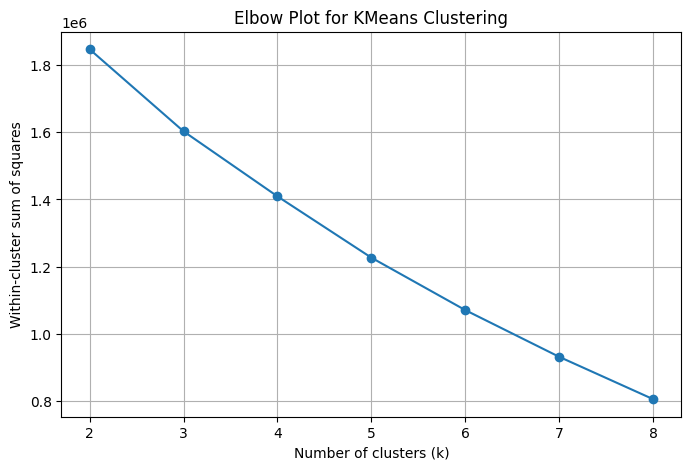

In [55]:
plt.figure(figsize=(8, 5))

plt.plot(k_results["k"], k_results["inertia"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Within-cluster sum of squares")
plt.title("Elbow Plot for KMeans Clustering")
plt.xticks(k_results["k"])
plt.grid(True)

plt.show()

In [78]:
final_k = 4

kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

df_model["segment"] = kmeans.fit_predict(X_segment_reduced)

## Cluster explaining

In [79]:
segment_profile = (
    df_model
    .groupby("segment")
    .agg(
        count=("label", "count"),
        over_50k_rate=("label", "mean"),
        avg_age=("age", "mean"),
        avg_education=("education_ordinal", "mean"),
        avg_weeks_worked=("weeks worked in year", "mean"),
        avg_wage=("wage per hour", "mean"),
        capital_gain_rate=("capital gains_is_nonzero", "mean"),
        dividend_rate=("dividends from stocks_is_nonzero", "mean")
    )
    .reset_index()
)

segment_profile["over_50k_rate"] *= 100
segment_profile["capital_gain_rate"] *= 100
segment_profile["dividend_rate"] *= 100

segment_profile

,segment,count,over_50k_rate,avg_age,avg_education,avg_weeks_worked,avg_wage,capital_gain_rate,dividend_rate
0,0,44332,1.529369,58.234075,8.348507,1.568235,0.226135,3.345213,13.753045
1,1,57230,0.001747,8.813402,0.982299,0.394094,0.569649,0.015726,0.159008
2,2,94055,11.199830,38.528053,10.022317,46.464239,113.793908,6.259104,14.860454
3,3,3906,29.928315,44.189964,10.636201,41.386073,80.243472,0.000000,24.987199


In [80]:
def top_categories_by_segment(df, segment_col, category_col, top_n=5):
    result = (
        df.groupby(segment_col)[category_col]
        .value_counts(normalize=True)
        .rename("percentage")
        .reset_index()
    )
    
    result["percentage"] = result["percentage"] * 100
    
    result = (
        result
        .sort_values([segment_col, "percentage"], ascending=[True, False])
        .groupby(segment_col)
        .head(top_n)
    )
    
    return result

def plot_top_categories_by_segment(df, segment_col, category_col, top_n=5):
    top_df = top_categories_by_segment(
        df,
        segment_col,
        category_col,
        top_n=top_n
    )
    
    pivot_df = top_df.pivot(
        index=category_col,
        columns=segment_col,
        values="percentage"
    ).fillna(0)
    
    pivot_df.plot(
        kind="bar",
        figsize=(12, 6)
    )
    
    plt.ylabel("Percentage within Segment")
    plt.xlabel(category_col)
    plt.title(f"Top {top_n} {category_col} Categories by Segment")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Segment")
    plt.tight_layout()
    plt.show()

In [74]:
categorical_profile_cols = [
    "education",
    "major occupation code",
    "major industry code",
    "class of worker",
    "full or part time employment stat",
    "marital_group",
    "detailed household summary in household"
]

for col in categorical_profile_cols:
    print(f"\nTop categories for {col}")
    display(top_categories_by_segment(df_model, "segment", col, top_n=5))


Top categories for education


,segment,education,percentage
0,0,High school graduate,35.674005
1,0,Some college but no degree,15.413246
2,0,7th and 8th grade,9.889019
3,0,Bachelors degree(BA AB BS),8.235586
4,0,10th grade,5.580619
16,1,Children,82.862135
17,1,9th grade,4.525598
18,1,10th grade,3.900052
19,1,7th and 8th grade,3.084047
20,1,11th grade,2.624498



Top categories for major occupation code


,segment,major occupation code,percentage
0,0,Not in universe,93.196788
1,0,Other service,1.265452
2,0,Adm support including clerical,0.999278
3,0,Sales,0.803032
4,0,Precision production craft & repair,0.631598
15,1,Not in universe,97.538005
16,1,Other service,0.819500
17,1,Sales,0.375677
18,1,Handlers equip cleaners etc,0.351214
19,1,Farming forestry and fishing,0.241132



Top categories for major industry code


,segment,major industry code,percentage
0,0,Not in universe or children,93.196788
1,0,Retail trade,1.337634
2,0,Construction,0.563927
3,0,Business and repair services,0.536858
4,0,Agriculture,0.527835
24,1,Not in universe or children,97.538005
25,1,Retail trade,1.027433
26,1,Agriculture,0.200944
27,1,Private household services,0.178228
28,1,Business and repair services,0.167744



Top categories for class of worker


,segment,class of worker,percentage
0,0,Not in universe,93.009564
1,0,Private,4.470811
2,0,Self-employed-not incorporated,1.391771
3,0,Local government,0.342867
4,0,State government,0.221059
9,1,Not in universe,96.936921
10,1,Private,2.072340
11,1,Never worked,0.601083
12,1,Self-employed-not incorporated,0.174734
13,1,Local government,0.097851



Top categories for full or part time employment stat


,segment,full or part time employment stat,percentage
0,0,Children or Armed Forces,48.736804
1,0,Not in labor force,48.197690
2,0,Full-time schedules,1.481999
3,0,Unemployed full-time,1.044392
4,0,Unemployed part- time,0.232338
8,1,Children or Armed Forces,92.507426
9,1,Not in labor force,6.269439
10,1,Full-time schedules,0.634283
11,1,Unemployed part- time,0.340730
12,1,Unemployed full-time,0.209680



Top categories for marital_group


,segment,marital_group,percentage
0,0,Divorced_or_Married,64.910223
1,0,Other,35.089777
2,1,Other,99.673248
3,1,Divorced_or_Married,0.326752
4,2,Divorced_or_Married,69.388124
5,2,Other,30.611876
6,3,Divorced_or_Married,69.278034
7,3,Other,30.721966



Top categories for detailed household summary in household


,segment,detailed household summary in household,percentage
0,0,Householder,52.082018
1,0,Spouse of householder,34.568709
2,0,Other relative of householder,5.438509
3,0,Child 18 or older,5.366327
4,0,Nonrelative of householder,2.377515
8,1,Child under 18 never married,85.350341
9,1,Other relative of householder,7.850778
10,1,Child 18 or older,3.248296
11,1,Nonrelative of householder,2.636729
12,1,Householder,0.636030
